# SHAP-Rule aplicado a Churn en Telecomunicaciones (v2)
### Explicaciones lingüísticas difusas a partir de valores SHAP — Dataset Telco Customer Churn (Maven Analytics / IBM)

Este notebook adapta la metodología **SHAP-Rule** (Khalyasmaa, Matrenin & Eroshenko, *Mathematics* 2025, 13, 3355) al problema de predicción de fuga de clientes (churn) en telecomunicaciones.

**Diferencia frente a la v1 (`shap_rule_telco_churn.ipynb`):** las Fases 1-3 (carga, EDA y preprocesamiento) ya no se escriben desde cero: se reutiliza el pipeline de `scripts/eda_churn_v1.py` + `scripts/eda_p1_ml.py`, que corre sobre el dataset más completo de **Maven Analytics/IBM** (7043 clientes, 38 columnas, vía `kagglehub`) e incluye limpieza que la v1 no tenía (imputación estructural fit-free, corrección de `Monthly Charge` negativo, diagnóstico de varianza casi nula/outliers/VIF). De ese pipeline se toma **solo la rama de árboles** (categóricas con codificación ordinal, numéricas sin escalar): la rama de regresión logística (one-hot + `StandardScaler`) de `eda_p1_ml.py` no aplica aquí porque SHAP-Rule usa `TreeExplainer` sobre Random Forest/LightGBM.

**Pipeline:**
1. Carga y auditoría del dataset (fuga de información / *leakage*, columnas sin valor predictivo)
2. Análisis exploratorio (EDA) sobre el set de entrenamiento ya limpio (balance de clases, distribuciones, tasas de churn, varianza casi nula, outliers IQR, correlación y eliminación por VIF)
3. Preprocesamiento: codificación ordinal para árboles (fit solo en train)
4. Modelado con ensambles: **Random Forest** y **LightGBM** (`GridSearchCV`)
5. Implementación de **SHAP-Rule**: términos lingüísticos vía arcsinh + cuartiles de Tukey, funciones de membresía triangulares, selección top-q (umbral T, tope K) y fuerza de activación α
6. Generación de explicaciones en tres formatos: **SHAP** (completo), **SHAP-L** (limitado) y **SHAP-R** (regla lingüística difusa), y evaluación comparativa: tiempo de ejecución, complejidad, cobertura, fidelidad y consistencia (similitud de Levenshtein)
7. Conclusiones

In [1]:
import sys, time, warnings
from pathlib import Path

# 'eda_churn_v1' vive en scripts/, un nivel arriba de docs/ -- se agrega al
# path para poder importarlo sin duplicar su código en el notebook.
SCRIPTS_DIR = Path.cwd().resolve().parent / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import Levenshtein
import shap
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, precision_recall_fscore_support
from sklearn.preprocessing import OrdinalEncoder

from eda_churn_v1 import (
    RANDOM_STATE,
    DROP_COLS,
    load_data,
    build_target,
    split_data,
    imputar_estructural,
    corregir_monthly_charge,
    get_X_y,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)

# Hiperparámetros de SHAP-Rule (mismos valores que el paper: K=4, T=0.8, alfa>=0.33)
K_MAX = 4          # máximo de antecedentes en la regla
T_CUM = 0.80       # umbral acumulado de importancia SHAP normalizada
ALPHA_MIN = 0.33   # umbral de activación para cobertura

## 1. Carga de datos y auditoría de columnas

El dataset de **Maven Analytics** (`shilongzhuang/telecom-customer-churn-by-maven-analytics` en Kaggle, cargado con `kagglehub` a través de `load_data()`) contiene 7043 clientes y 38 columnas, más un dataset auxiliar de población por código postal que no se usa aquí. Es una versión más completa que el Telco IBM clásico (33 columnas): agrega `Age`, `Number of Dependents`, `Number of Referrals`, cargos de larga distancia, reembolsos (`Total Refunds`) y el detalle de `Customer Status` en tres grupos (`Stayed`, `Churned`, `Joined`) en vez de un flag binario directo.

**Columnas descartadas** (`DROP_COLS` en `eda_churn_v1.py`), por los mismos motivos que en la v1:
* `Customer ID` → identificador, sin señal predictiva.
* `City`, `Zip Code`, `Latitude`, `Longitude` → geografía cruda de alta cardinalidad, redundante con lat/long.
* `Churn Category`, `Churn Reason` → derivadas del resultado de churn (leakage directo).
* `Customer Status` → se reemplaza por el target binario `Churn_Flag` (ver más abajo); dejarla como feature sería filtrar el label.

In [2]:
df, pop = load_data()
print(f"Dataset original: {df.shape} | Población por zip: {pop.shape}")
df.head(3)

Dataset original: (7043, 38) | Población por zip: (1671, 2)


,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices


In [3]:
# Diagnóstico: 'Monthly Charge' negativo (descriptivo, sobre TODO el dataset,
# antes de cualquier estadístico que dependa del split).
cols_diag = ["Monthly Charge", "Total Charges", "Tenure in Months", "Customer Status"]
negativos_mc = df.loc[df["Monthly Charge"] < 0, cols_diag]
print(f"Monthly Charge negativos: {len(negativos_mc)} (de {len(df)})")
negativos_mc.head()

Monthly Charge negativos: 120 (de 7043)


,Monthly Charge,Total Charges,Tenure in Months,Customer Status
1,-4.0,542.40,9,Stayed
32,-2.0,7942.15,66,Stayed
170,-3.0,465.70,7,Stayed
232,-8.0,4539.60,68,Stayed
336,-1.0,343.95,5,Churned


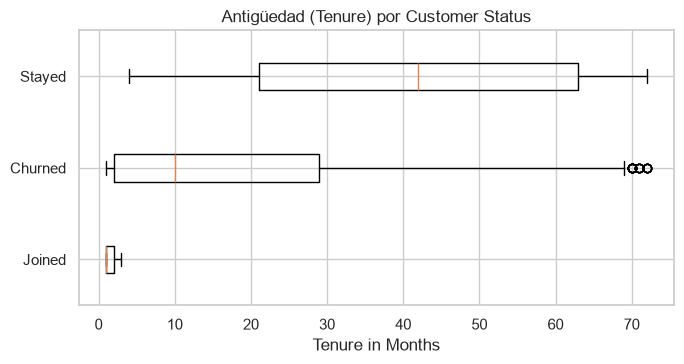

                 min   25%   50%   75%   max
Customer Status                             
Churned          1.0   2.0  10.0  29.0  72.0
Joined           1.0   1.0   1.0   2.0   3.0
Stayed           4.0  21.0  42.0  63.0  72.0


In [4]:
# Diagnóstico: Tenure por Customer Status -- valida los 3 grupos (Joined/Churned/
# Stayed) ANTES de que build_target() excluya a 'Joined' del modelado.
orden_status = ["Joined", "Churned", "Stayed"]
datos_tenure = [df.loc[df["Customer Status"] == s, "Tenure in Months"] for s in orden_status]

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.boxplot(datos_tenure, tick_labels=orden_status, vert=False)
ax.set_xlabel("Tenure in Months")
ax.set_title("Antigüedad (Tenure) por Customer Status")
plt.tight_layout(); plt.show()

print(df.groupby("Customer Status")["Tenure in Months"].describe()[["min", "25%", "50%", "75%", "max"]])

`Joined` son clientes recién dados de alta este trimestre: su tenure es casi 0 y todavía no tuvieron oportunidad de irse. `build_target()` los excluye del modelado (si se dejaran, quedarían codificados como "no churn" igual que `Stayed`, contaminando el target con un desenlace que aún se desconoce) y define `Churn_Flag = 1` para `Churned`, `0` para `Stayed`.

In [5]:
df = build_target(df)
print(f"Dataset tras excluir 'Joined': {df.shape}")
TARGET = "Churn_Flag"

Clientes 'Joined' excluidos del modelado: 454 (de 7043)
Dataset tras excluir 'Joined': (6589, 39)


## 2. Análisis exploratorio (EDA)

A diferencia de la v1 (que hacía el EDA sobre el dataset completo antes de partirlo), aquí se sigue el orden de `eda_p1_ml.py`: primero se **parte en train/test** y se **limpian** los valores inválidos, y **recién entonces** se calculan estadísticos descriptivos, outliers y correlaciones — todos ellos únicamente sobre `train`, para que ninguna decisión de preprocesamiento (mediana de imputación, cuartiles, VIF) se contamine con información de test.

### 2.1 Partición estratificada 80/20 y limpieza fit-free

In [6]:
df_train, df_test = split_data(df)  # 80/20 estratificado, random_state=42 (protocolo del paper, Sección 4.3)

# Imputación estructural: reglas fijas del diccionario de datos (p. ej. sin
# Internet Service -> "No Internet Service"), no estadísticos -- se aplica
# igual en train y test, sin riesgo de leakage.
df_train = imputar_estructural(df_train)
df_test = imputar_estructural(df_test)

# Corrección de 'Monthly Charge' negativo (sin interpretación de negocio
# válida) con la MEDIANA DE TRAIN, aplicada a ambos particiones.
df_train, df_test = corregir_monthly_charge(df_train, df_test)

print(f"Nulos tras limpieza -> train: {df_train.isnull().sum().sum()} | test: {df_test.isnull().sum().sum()}")

Train: (5271, 39) | Test: (1318, 39)
Tasa de churn -> train: 0.284 | test: 0.284
Monthly Charge negativo corregido con mediana de train (73.15): train=90 filas, test=24 filas
Nulos tras limpieza -> train: 7552 | test: 1888


### 2.2 Balance de clases (train)

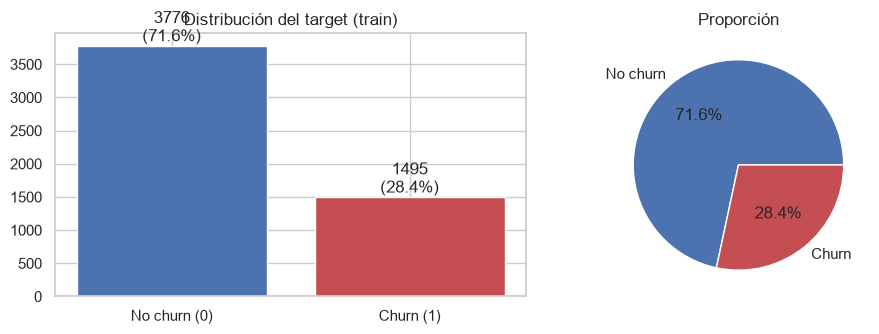

Tasa de churn -> train: 0.284 | test: 0.284
Desbalance moderado (~28%), comparable al Pima Diabetes del paper (35/65).


In [7]:
X_train_raw, y_train = get_X_y(df_train)
X_test_raw, y_test = get_X_y(df_test)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
counts = y_train.value_counts()
ax[0].bar(["No churn (0)", "Churn (1)"], counts.values, color=["#4C72B0", "#C44E52"])
ax[0].set_title("Distribución del target (train)")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f"{v}\n({v/len(y_train):.1%})", ha="center", va="bottom")
ax[1].pie(counts.values, labels=["No churn", "Churn"], autopct="%1.1f%%", colors=["#4C72B0", "#C44E52"])
ax[1].set_title("Proporción")
plt.tight_layout(); plt.show()
print(f"Tasa de churn -> train: {y_train.mean():.3f} | test: {y_test.mean():.3f}")
print("Desbalance moderado (~28%), comparable al Pima Diabetes del paper (35/65).")

### 2.3 Variables numéricas y categóricas

In [8]:
num_feats = X_train_raw.select_dtypes(include=np.number).columns.tolist()
cat_feats = X_train_raw.select_dtypes(exclude=np.number).columns.tolist()
print(f"Numéricas ({len(num_feats)}): {num_feats}")
print(f"\nCategóricas ({len(cat_feats)}): {cat_feats}")

Numéricas (12): ['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']

Categóricas (18): ['Gender', 'Married', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']


### 2.4 Variables numéricas vs. churn

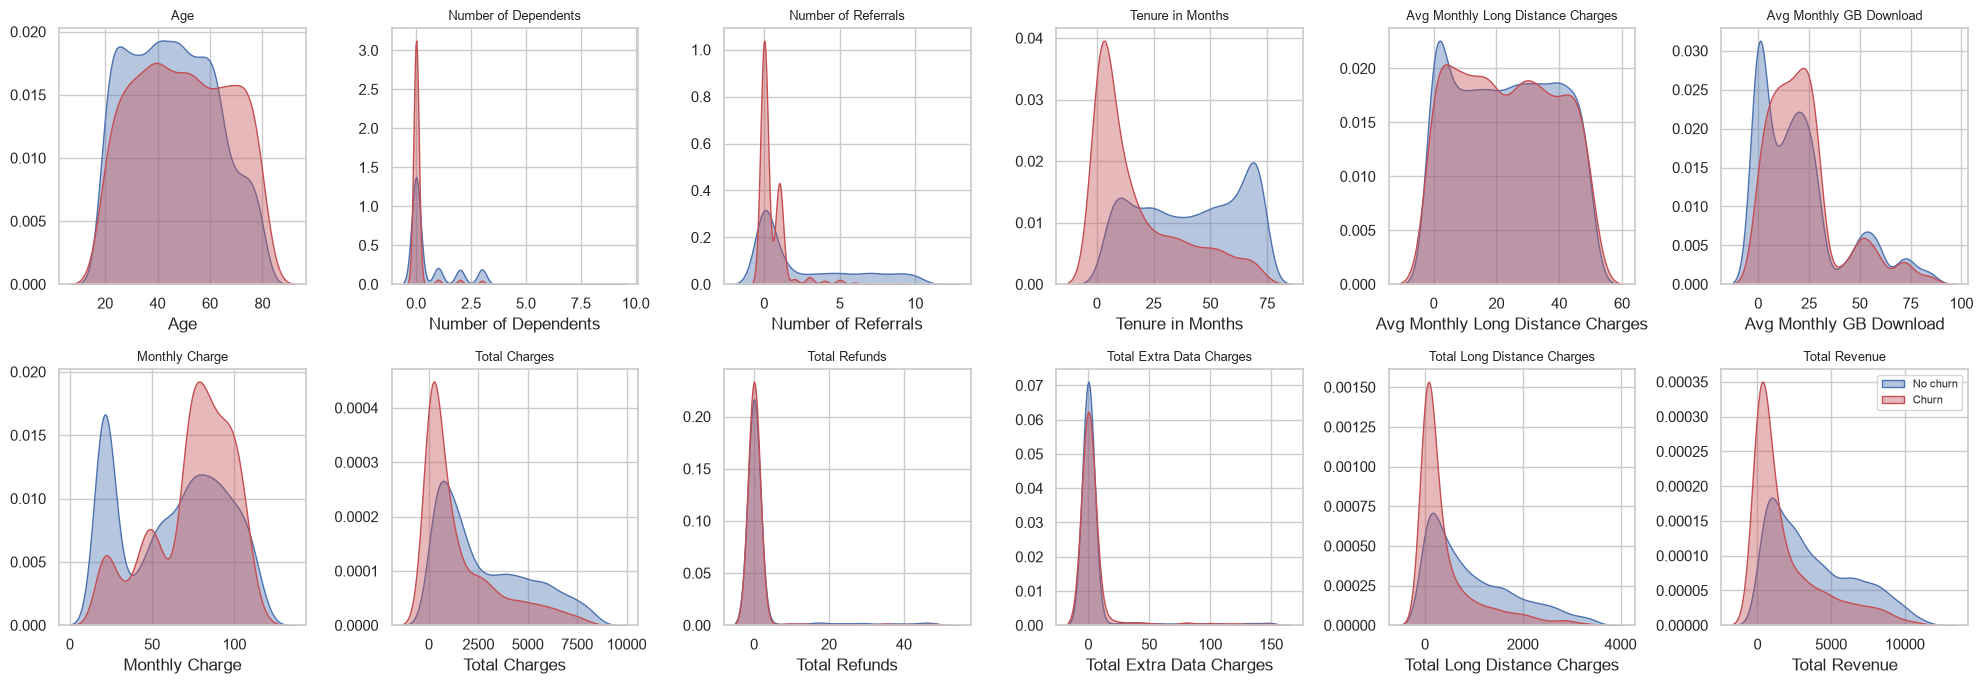

In [9]:
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for ax, col in zip(axes.ravel(), num_feats):
    for val, color, lab in [(0, "#4C72B0", "No churn"), (1, "#C44E52", "Churn")]:
        sns.kdeplot(X_train_raw.loc[y_train == val, col], ax=ax, fill=True, alpha=0.4, color=color, label=lab)
    ax.set_title(col, fontsize=9); ax.set_ylabel("")
axes.ravel()[-1].legend(fontsize=8)
for ax in axes.ravel()[len(num_feats):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

### 2.5 Tasa de churn por variable categórica

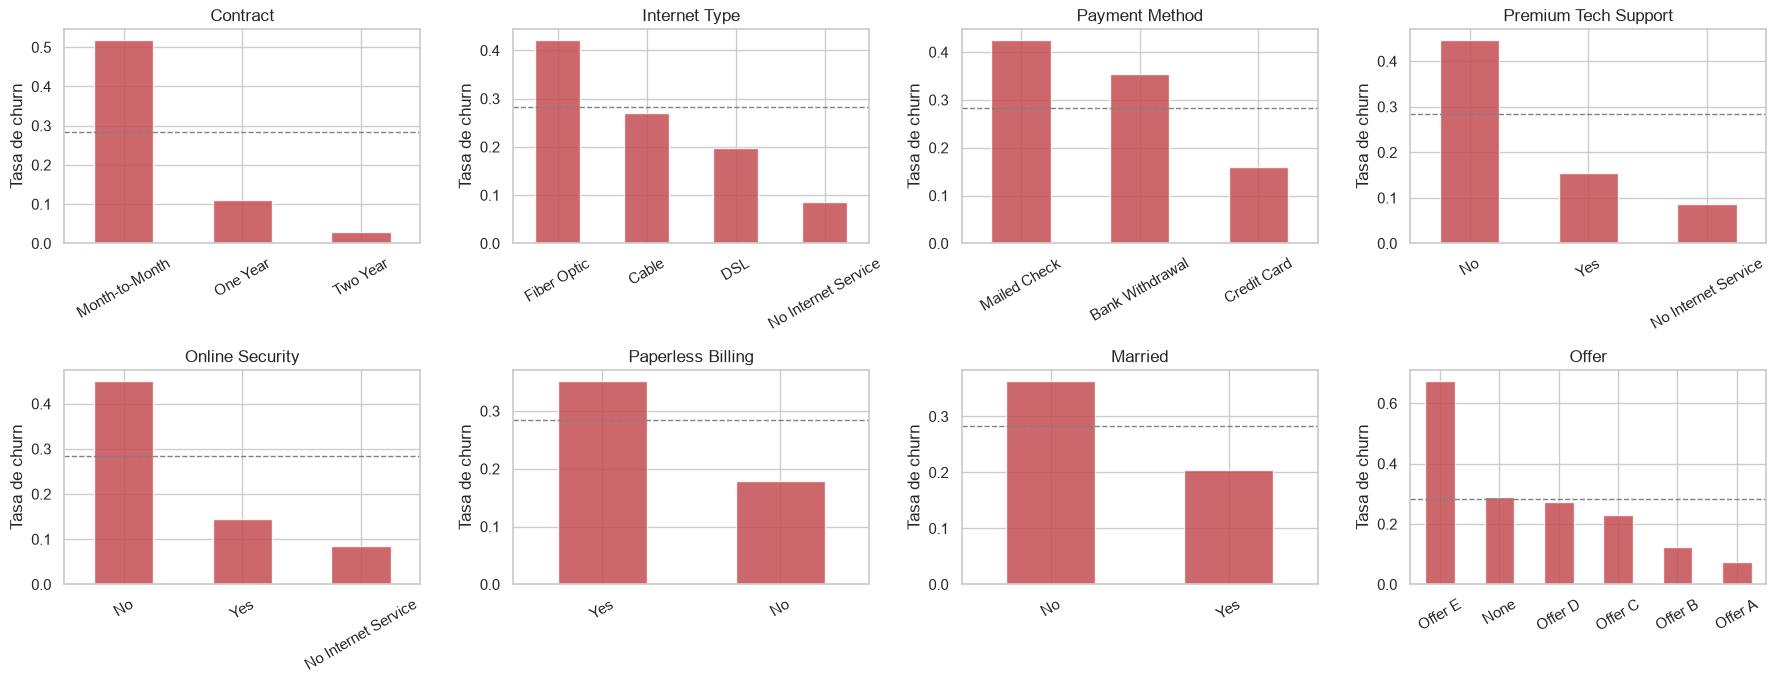

In [10]:
key_cats = ["Contract", "Internet Type", "Payment Method", "Premium Tech Support",
            "Online Security", "Paperless Billing", "Married", "Offer"]
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for ax, col in zip(axes.ravel(), key_cats):
    rate = X_train_raw.join(y_train).groupby(col)[TARGET].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#C44E52", alpha=0.85)
    ax.axhline(y_train.mean(), ls="--", c="gray", lw=1)
    ax.set_title(col); ax.set_ylabel("Tasa de churn"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### 2.6 Varianza casi nula

Diagnóstico, no elimina nada: numéricas donde un solo valor concentra casi todas las observaciones (candidatas a aportar poca señal, típicamente por ser variables condicionales — p. ej. cargos que solo aplican a una porción de clientes).

In [11]:
def detectar_varianza_casi_nula(X_train, feats, umbral=0.90):
    filas = [
        {
            "variable": c,
            "valor_mas_frecuente": X_train[c].value_counts().index[0],
            "proporcion": round(X_train[c].value_counts(normalize=True).iloc[0], 3),
        }
        for c in feats
    ]
    return pd.DataFrame(filas).sort_values("proporcion", ascending=False)

varianza_resumen = detectar_varianza_casi_nula(X_train_raw, num_feats)
varianza_resumen

,variable,valor_mas_frecuente,proporcion
8,Total Refunds,0.00,0.918
9,Total Extra Data Charges,0.00,0.899
1,Number of Dependents,0.00,0.769
2,Number of Referrals,0.00,0.524
5,Avg Monthly GB Download,0.00,0.205
4,Avg Monthly Long Distance Charges,0.00,0.096
10,Total Long Distance Charges,0.00,0.096
3,Tenure in Months,1.00,0.062
0,Age,47.00,0.023
6,Monthly Charge,73.15,0.017


### 2.7 Descriptivos y sesgo (insumo directo para los términos difusos de SHAP-Rule, Fase 5)

In [12]:
def resumen_descriptivo_numericas(X_train, feats):
    tabla = pd.DataFrame({
        "media": X_train[feats].mean(),
        "mediana": X_train[feats].median(),
        "skew": X_train[feats].skew(),
    }).round(2)
    tabla["forma"] = tabla["skew"].apply(
        lambda s: "Simétrica" if abs(s) < 0.5 else ("Cola derecha" if s > 0 else "Cola izquierda")
    )
    return tabla

descriptivos = resumen_descriptivo_numericas(X_train_raw, num_feats)
descriptivos

,media,mediana,skew,forma
Age,46.76,46.00,0.16,Simétrica
Number of Dependents,0.47,0.00,2.10,Cola derecha
Number of Referrals,2.02,0.00,1.39,Cola derecha
Tenure in Months,34.63,33.00,0.14,Simétrica
Avg Monthly Long Distance Charges,23.06,22.95,0.05,Simétrica
Avg Monthly GB Download,20.84,17.00,1.21,Cola derecha
Monthly Charge,66.43,73.15,-0.30,Simétrica
Total Charges,2449.87,1567.00,0.87,Cola derecha
Total Refunds,2.14,0.00,4.13,Cola derecha
Total Extra Data Charges,7.12,0.00,4.01,Cola derecha


### 2.8 Outliers por IQR (regla de Tukey 1.5·IQR, solo train)

In [13]:
def detectar_outliers_iqr(X_train, feats):
    filas = []
    for c in feats:
        q1, q3 = X_train[c].quantile(0.25), X_train[c].quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_outliers = int(((X_train[c] < lo) | (X_train[c] > hi)).sum())
        filas.append({"variable": c, "limite_inferior": round(lo, 2), "limite_superior": round(hi, 2),
                      "n_outliers": n_outliers, "pct": round(100 * n_outliers / len(X_train), 2)})
    return pd.DataFrame(filas).sort_values("n_outliers", ascending=False)

outliers_resumen = detectar_outliers_iqr(X_train_raw, num_feats)
outliers_resumen

,variable,limite_inferior,limite_superior,n_outliers,pct
1,Number of Dependents,0.00,0.00,1219,23.13
9,Total Extra Data Charges,0.00,0.00,532,10.09
2,Number of Referrals,-4.50,7.50,516,9.79
8,Total Refunds,0.00,0.00,431,8.18
5,Avg Monthly GB Download,-30.50,61.50,280,5.31
10,Total Long Distance Charges,-1668.23,3064.51,99,1.88
11,Total Revenue,-5695.04,11692.76,1,0.02
0,Age,-7.50,100.50,0,0.00
3,Tenure in Months,-55.50,124.50,0,0.00
7,Total Charges,-4746.76,9333.34,0,0.00


### 2.9 Correlación de Pearson y eliminación de multicolineales por VIF

Igual que en `eda_p1_ml.py`: se calcula el VIF (Variance Inflation Factor) de las numéricas y se elimina iterativamente la de mayor VIF hasta que todas queden bajo el umbral (10.0). Es clave para SHAP-Rule: dos variables casi redundantes (p. ej. `Total Charges` ≈ `Tenure × Monthly Charge`, o `Total Revenue` que resume varias de las anteriores) diluirían artificialmente entre sí la importancia SHAP y podrían generar dos antecedentes lingüísticos que dicen casi lo mismo.

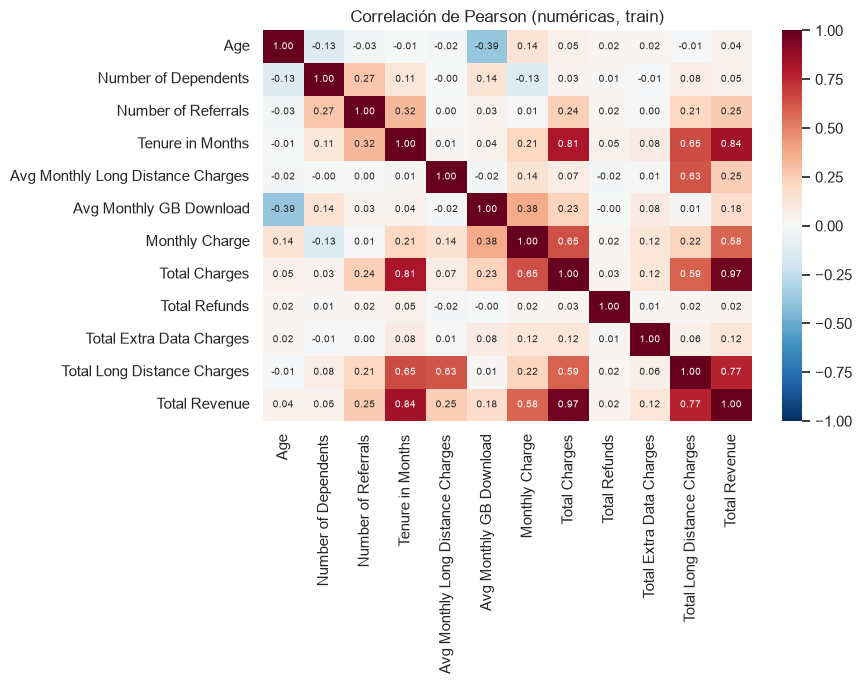

Pares con |r| >= 0.7:
  Tenure in Months <-> Total Charges: r = 0.815
  Tenure in Months <-> Total Revenue: r = 0.842
  Total Charges <-> Total Revenue: r = 0.971
  Total Long Distance Charges <-> Total Revenue: r = 0.768


In [14]:
corr = X_train_raw[num_feats].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, annot_kws={"size": 7})
plt.title("Correlación de Pearson (numéricas, train)"); plt.tight_layout(); plt.show()

print(f"Pares con |r| >= 0.7:")
for i, c1 in enumerate(num_feats):
    for c2 in num_feats[i + 1:]:
        r = corr.loc[c1, c2]
        if abs(r) >= 0.7:
            print(f"  {c1} <-> {c2}: r = {r:.3f}")

In [15]:
def calcular_vif(X_train, feats):
    filas = []
    for c in feats:
        otras = [f for f in feats if f != c]
        modelo = LinearRegression().fit(X_train[otras], X_train[c])
        r2 = modelo.score(X_train[otras], X_train[c])
        vif = np.inf if r2 >= 0.9999 else 1 / (1 - r2)
        filas.append({"variable": c, "r2": round(r2, 4), "VIF": vif})
    return pd.DataFrame(filas).sort_values("VIF", ascending=False, kind="stable")

def eliminar_multicolineales_vif(X_train, feats, umbral_vif=10.0):
    restantes = list(feats)
    paso = 1
    while len(restantes) > 1:
        tabla = calcular_vif(X_train, restantes)
        peor = tabla.iloc[0]
        print(f"--- VIF paso {paso} --- peor: {peor['variable']} (VIF={peor['VIF']:.2f})")
        if peor["VIF"] <= umbral_vif:
            break
        restantes.remove(peor["variable"])
        paso += 1
    return restantes

numericas_finales = eliminar_multicolineales_vif(X_train_raw, num_feats, umbral_vif=10.0)
eliminadas_vif = [c for c in num_feats if c not in numericas_finales]
print(f"\nEliminadas por VIF > 10: {eliminadas_vif}")
print(f"Numéricas finales ({len(numericas_finales)} de {len(num_feats)}): {numericas_finales}")

--- VIF paso 1 --- peor: Total Charges (VIF=inf)
--- VIF paso 2 --- peor: Total Revenue (VIF=16.42)
--- VIF paso 3 --- peor: Total Long Distance Charges (VIF=5.39)

Eliminadas por VIF > 10: ['Total Charges', 'Total Revenue']
Numéricas finales (10 de 12): ['Age', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges']


`Total Charges` y `Total Revenue` se eliminan por VIF infinito/alto: son, casi por construcción contable, combinaciones lineales de `Tenure in Months`, `Monthly Charge` y los cargos de larga distancia/reembolsos que sí se conservan. Quedan **10 numéricas finales** de las 12 originales.

## 3. Preprocesamiento: codificación ordinal para árboles

Se toma **solo la Rama A (árboles)** de `eda_p1_ml.py`: categóricas con **codificación ordinal** (`OrdinalEncoder`, `fit` solo en train) y numéricas **sin escalar** — los ensambles de árboles dividen por umbral columna por columna, así que son invariantes a la escala y al orden arbitrario que impone un entero. Se omite la Rama B (one-hot + `StandardScaler` para regresión logística) porque SHAP-Rule usa `TreeExplainer`, que solo aplica a modelos de árboles.

Se mantiene además un DataFrame paralelo con los valores **originales** (`Xr_tr`/`Xr_te`) para redactar los antecedentes lingüísticos de las reglas SHAP-R.

In [16]:
def convertir_categoricas_ordinal(df_train, df_test, cat_feats):
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    df_train_enc, df_test_enc = df_train.copy(), df_test.copy()
    df_train_enc[cat_feats] = encoder.fit_transform(df_train[cat_feats])
    df_test_enc[cat_feats] = encoder.transform(df_test[cat_feats])
    return df_train_enc, df_test_enc, encoder

df_train_ord, df_test_ord, ordinal_encoder = convertir_categoricas_ordinal(df_train, df_test, cat_feats)

X_train_ord_full, y_train = get_X_y(df_train_ord)
X_test_ord_full, y_test = get_X_y(df_test_ord)

# Columnas finales: numéricas post-VIF + todas las categóricas (codificadas ordinal)
columnas_finales = numericas_finales + cat_feats
X_tr = X_train_ord_full[columnas_finales].copy()
X_te = X_test_ord_full[columnas_finales].copy()
# numéricas a float (necesario para las perturbaciones gaussianas de la Sección 6.2;
# varias llegan como int64 -- p. ej. Age, Tenure in Months -- y sin este cast la
# asignación de un delta gaussiano falla con dtype int)
X_tr[numericas_finales] = X_tr[numericas_finales].astype(float)
X_te[numericas_finales] = X_te[numericas_finales].astype(float)

# Paralelo con valores originales (para las reglas lingüísticas de SHAP-Rule)
Xr_tr = X_train_raw[columnas_finales].copy()
Xr_te = X_test_raw[columnas_finales].copy()
Xr_tr[numericas_finales] = Xr_tr[numericas_finales].astype(float)
Xr_te[numericas_finales] = Xr_te[numericas_finales].astype(float)

NUM_COLS = numericas_finales
CAT_COLS = cat_feats
print(f"X_tr: {X_tr.shape} | X_te: {X_te.shape}  ({len(NUM_COLS)} numéricas + {len(CAT_COLS)} categóricas)")

X_tr: (5271, 28) | X_te: (1318, 28)  (10 numéricas + 18 categóricas)


## 4. Modelado con ensambles (Random Forest y LightGBM)

Igual que en el paper, el objetivo **no** es maximizar la exactitud sino disponer de modelos de caja negra estándar, ajustados con `GridSearchCV`, cuyas predicciones serán explicadas. Se usa `class_weight`/`scale_pos_weight` por el desbalance moderado del target (~28% churn en train).

In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

param_rf = {"n_estimators": [100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [4, 6]}
param_lgb = {"n_estimators": [100, 200],
             "max_depth": [3, 5],
             "learning_rate": [0.05, 0.1]}

gs_rf = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
                     param_rf, cv=3, scoring="f1_weighted", n_jobs=-1).fit(X_tr, y_train)
gs_lgb = GridSearchCV(lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, scale_pos_weight=scale_pos_weight),
                      param_lgb, cv=3, scoring="f1_weighted", n_jobs=-1).fit(X_tr, y_train)

rf, lgbm = gs_rf.best_estimator_, gs_lgb.best_estimator_
print("RF   ->", gs_rf.best_params_)
print("LGBM ->", gs_lgb.best_params_)

RF   -> {'max_depth': None, 'min_samples_split': 4, 'n_estimators': 100}
LGBM -> {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}


In [18]:
rows = []
for name, m in [("Random Forest", rf), ("LightGBM", lgbm)]:
    p = m.predict(X_te)
    pr, rc, f1, _ = precision_recall_fscore_support(y_test, p, average="weighted")
    rows.append([name, round(rc, 3), round(pr, 3), round(f1, 3)])
    print(f"===== {name} =====")
    print(classification_report(y_test, p, target_names=["No churn", "Churn"]))
metrics_df = pd.DataFrame(rows, columns=["Modelo", "Recall (w)", "Precision (w)", "F1 (w)"])
metrics_df

===== Random Forest =====
              precision    recall  f1-score   support

    No churn       0.90      0.90      0.90       944
       Churn       0.75      0.74      0.75       374

    accuracy                           0.86      1318
   macro avg       0.82      0.82      0.82      1318
weighted avg       0.86      0.86      0.86      1318

===== LightGBM =====
              precision    recall  f1-score   support

    No churn       0.91      0.87      0.89       944
       Churn       0.70      0.78      0.74       374

    accuracy                           0.84      1318
   macro avg       0.81      0.83      0.81      1318
weighted avg       0.85      0.84      0.85      1318



,Modelo,Recall (w),Precision (w),F1 (w)
0,Random Forest,0.856,0.856,0.856
1,LightGBM,0.844,0.851,0.846


## 5. Metodología SHAP-Rule

Se implementan las cinco etapas del paper (Sección 3):

**5.1 Generación automática de términos difusos (arcsinh + cuartiles de Tukey).** Para cada una de las **10 numéricas finales** del *train* se aplica $L_i=\operatorname{arcsinh}(x_i)$ (Ec. 1), se calculan $Q_1,Q_2,Q_3$, el IQR y los puntos externos $\max(L_{min},Q_1-1.5\,IQR)$ y $\min(L_{max},Q_3+1.5\,IQR)$ (Ecs. 2–8). Las 7 fronteras se devuelven a la escala original con $\sinh$ (Ec. 9) y se podan términos redundantes (fronteras coincidentes). Los 7 términos posibles: *extremadamente bajo, bajo, por debajo del promedio, promedio, por encima del promedio, alto, extremadamente alto*.

**Adaptación al dominio telco:** las variables **categóricas** ya son lingüísticas por naturaleza (p. ej. `Contract es Month-to-Month`), por lo que se usan directamente como antecedentes con membresía $\mu=1$; los términos difusos se aplican solo a las numéricas.

**Nota sobre variables con muchos ceros.** `Number of Dependents`, `Total Refunds` y `Total Extra Data Charges` tienen entre 77% y 92% de observaciones en 0 (ver 2.6): sus cuartiles Q1/Q3 caen ambos en 0, por lo que el algoritmo de poda colapsa sus 7 términos posibles a uno solo (`promedio`, con μ=1 para cualquier valor ≥ 0). Es una consecuencia esperada del método aplicado a variables tan concentradas en un punto, no un error: para esas tres columnas el antecedente lingüístico siempre se satisface y no aporta información discriminante, algo distinto a las 7 numéricas restantes donde sí se preservan varios términos.

In [19]:
TERMS = ["extremadamente bajo", "bajo", "por debajo del promedio", "promedio",
         "por encima del promedio", "alto", "extremadamente alto"]

def build_fuzzy_terms(series: pd.Series) -> dict:
    # Ecs. (1)-(9): arcsinh -> cuartiles + cercas de Tukey -> sinh -> poda de redundantes.
    # Devuelve {termino: (a, b, c)} para MF triangulares (hombros en los extremos).
    L = np.arcsinh(series.values.astype(float))
    q1, q2, q3 = np.percentile(L, [25, 50, 75])
    iqr = q3 - q1
    B_L = [L.min(), max(L.min(), q1 - 1.5 * iqr), q1, q2, q3,
           min(L.max(), q3 + 1.5 * iqr), L.max()]
    B = np.sinh(B_L)                       # regreso a escala original
    kept = {3: B[3]}                       # 'promedio' (mediana) siempre se incluye
    for i in (2, 1, 0):                    # lado izquierdo
        if B[i] < B[i + 1]: kept[i] = B[i]
        else: break
    for i in (4, 5, 6):                    # lado derecho
        if B[i] > B[i - 1]: kept[i] = B[i]
        else: break
    idxs = sorted(kept); pts = [kept[i] for i in idxs]
    mfs = {}
    for j, i in enumerate(idxs):
        a = pts[j - 1] if j > 0 else pts[j]
        b = pts[j]
        c = pts[j + 1] if j < len(pts) - 1 else pts[j]
        mfs[TERMS[i]] = (a, b, c)
    return mfs

def tri_mu(x, a, b, c):
    # MF triangular (Ec. 10) con hombros: el primer/ultimo termino satura fuera de rango.
    if a == b and x <= b: return 1.0
    if b == c and x >= b: return 1.0
    if x <= a or x >= c: return 0.0
    return (x - a) / (b - a) if x <= b else (c - x) / (c - b)

MFS = {col: build_fuzzy_terms(Xr_tr[col]) for col in NUM_COLS}
for col, mfs in MFS.items():
    print(f"\n{col} ({len(mfs)} termino(s)):")
    for t, (a, b, c) in mfs.items():
        print(f"   {t:<26} (a={a:10.2f}, b={b:10.2f}, c={c:10.2f})")


Age (5 termino(s)):
   bajo                       (a=     19.00, b=     19.00, c=     33.00)
   por debajo del promedio    (a=     19.00, b=     33.00, c=     46.00)
   promedio                   (a=     33.00, b=     46.00, c=     60.00)
   por encima del promedio    (a=     46.00, b=     60.00, c=     80.00)
   alto                       (a=     60.00, b=     80.00, c=     80.00)

Number of Dependents (1 termino(s)):
   promedio                   (a=      0.00, b=      0.00, c=      0.00)

Number of Referrals (3 termino(s)):
   promedio                   (a=      0.00, b=      0.00, c=      3.00)
   por encima del promedio    (a=      0.00, b=      3.00, c=     11.00)
   alto                       (a=      3.00, b=     11.00, c=     11.00)

Tenure in Months (5 termino(s)):
   bajo                       (a=      1.00, b=      1.00, c=     12.00)
   por debajo del promedio    (a=      1.00, b=     12.00, c=     33.00)
   promedio                   (a=     12.00, b=     33.00, c=     5

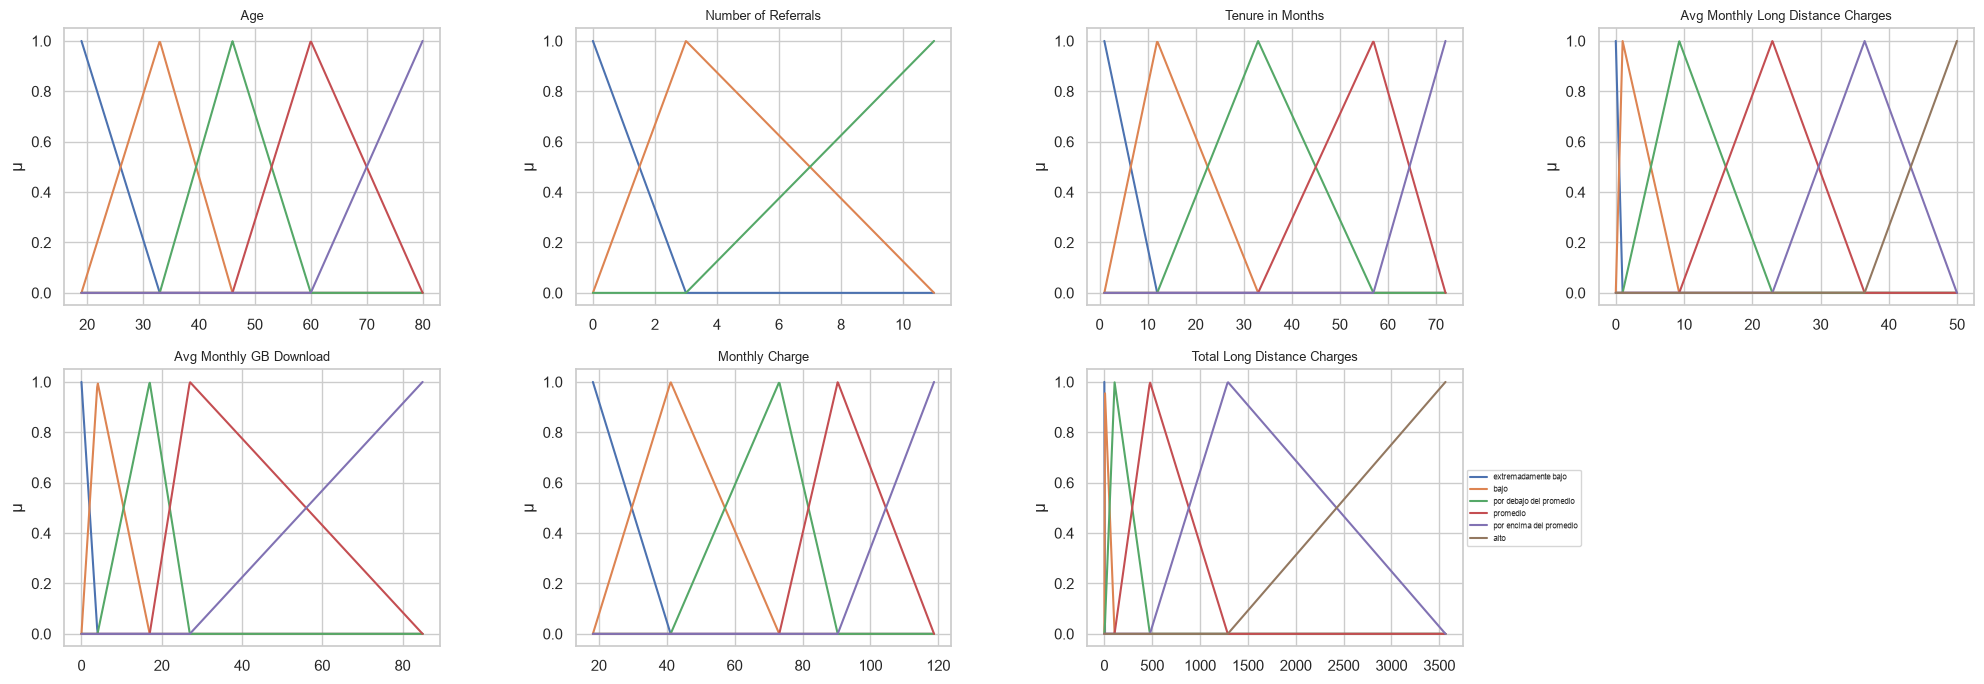

In [20]:
# Visualización de las funciones de membresía (solo las que conservan >1 término)
cols_a_graficar = [c for c in NUM_COLS if len(MFS[c]) > 1]
fig, axes = plt.subplots(2, 4, figsize=(20, 7))
for ax, col in zip(axes.ravel(), cols_a_graficar):
    xs = np.linspace(Xr_tr[col].min(), Xr_tr[col].max(), 500)
    for t, (a, b, c) in MFS[col].items():
        ax.plot(xs, [tri_mu(v, a, b, c) for v in xs], label=t)
    ax.set_title(col, fontsize=9); ax.set_ylabel("μ")
axes.ravel()[len(cols_a_graficar) - 1].legend(fontsize=6, loc="center left", bbox_to_anchor=(1, 0.5))
for ax in axes.ravel()[len(cols_a_graficar):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

**5.2 Valores SHAP, selección top-q y fuerza de activación.** Con `TreeExplainer` se obtiene $\varphi_j$ por instancia; se normaliza $w_j=|\varphi_j|/\sum_i|\varphi_i|$ (Ec. 11), se ordenan de forma descendente y se toman los primeros hasta que $\sum w \ge T$ con tope $K$ (Ecs. 12–15). La fuerza de activación de la regla es la media geométrica ponderada $\alpha=\prod_j \mu_j(x_j)^{1-w_j}$ (Ec. 16).

In [21]:
def make_explainers(model):
    expl = shap.TreeExplainer(model)
    def phi_matrix(X):
        sv = expl.shap_values(X)
        sv = np.array(sv)
        if sv.ndim == 3:                       # (n,F,2) sklearn  o  (2,n,F) lgbm
            sv = sv[..., 1] if sv.shape[-1] == 2 else sv[1]
        return sv
    return phi_matrix

def select_top_q(phi, K=K_MAX, T=T_CUM):
    # Ecs. (11)-(15): normaliza, ordena y corta por umbral acumulado T con tope K.
    w = np.abs(phi) / (np.abs(phi).sum() + 1e-12)
    order = np.argsort(-w)
    sel, cum = [], 0.0
    for j in order:
        sel.append(j); cum += w[j]
        if cum >= T or len(sel) >= K: break
    return sel, w

def best_term(col, x):
    return max(((t, tri_mu(x, *abc)) for t, abc in MFS[col].items()), key=lambda p: p[1])

def explain_instance(i, phi_row, model, mode):
    # Genera el texto de explicacion en formato 'shap', 'shap_l' o 'shap_r'.
    x_enc, x_raw = X_te.iloc[i], Xr_te.iloc[i]
    pred = int(model.predict(x_enc.to_frame().T)[0])
    consec = "Churn" if pred == 1 else "No churn"

    if mode == "shap":                          # todos los features, valores numéricos
        order = np.argsort(-np.abs(phi_row))
        parts = [f"{X_te.columns[j]} es {x_raw.iloc[j]} (SHAP {phi_row[j]:+.3f})" for j in order]
        return " Y ".join(parts) + f": {consec}", None, len(parts), pred

    sel, w = select_top_q(phi_row)
    if mode == "shap_l":                        # top-q, valores numéricos
        parts = [f"{X_te.columns[j]} es {x_raw.iloc[j]} (SHAP {phi_row[j]:+.3f})" for j in sel]
        return " Y ".join(parts) + f": {consec}", None, len(parts), pred

    # mode == 'shap_r': regla lingüística difusa + activación (Ec. 16)
    parts, alpha, antecedents = [], 1.0, []
    for j in sel:
        col = X_te.columns[j]
        if col in NUM_COLS:
            t, mu = best_term(col, float(x_raw[col]))
            parts.append(f"{col} es {t}")
            antecedents.append(("num", col, t))
        else:
            mu = 1.0
            parts.append(f"{col} es {x_raw[col]}")
            antecedents.append(("cat", col, x_raw[col]))
        alpha *= mu ** (1.0 - w[j])
    text = "SI " + " Y ".join(parts) + f" ENTONCES {consec}"
    return text, alpha, len(parts), pred, antecedents

phi_fn = {"Random Forest": make_explainers(rf), "LightGBM": make_explainers(lgbm)}

## 6. Formatos de explicación y evaluación comparativa

### 6.1 Los tres formatos sobre las mismas instancias de test

Análogo a la Sección 5.2 del paper (mostramos LightGBM; el bloque es reutilizable para RF).

In [22]:
MODEL_NAME, MODEL = "LightGBM", lgbm
PHI_TE = phi_fn[MODEL_NAME](X_te)   # matriz SHAP del test completo (precomputada)

for i in range(3):
    cid = df_test.loc[Xr_te.index[i], "Customer ID"]
    print(f"--- Instancia de test #{i} (cliente {cid}) ---")
    t_full, *_ = explain_instance(i, PHI_TE[i], MODEL, "shap")
    t_lim, *_ = explain_instance(i, PHI_TE[i], MODEL, "shap_l")
    t_rule, alpha, *_ = explain_instance(i, PHI_TE[i], MODEL, "shap_r")
    print("SHAP  :", t_full[:220] + " ...")
    print("SHAP-L:", t_lim)
    print(f"SHAP-R: {t_rule}   [α = {alpha:.3f}]\n")

--- Instancia de test #0 (cliente 5924-IFQTT) ---
SHAP  : Contract es Month-to-Month (SHAP +1.701) Y Number of Dependents es 2.0 (SHAP -1.548) Y Number of Referrals es 4.0 (SHAP -0.506) Y Premium Tech Support es Yes (SHAP -0.291) Y Online Security es No (SHAP +0.266) Y Total Lo ...
SHAP-L: Contract es Month-to-Month (SHAP +1.701) Y Number of Dependents es 2.0 (SHAP -1.548) Y Number of Referrals es 4.0 (SHAP -0.506) Y Premium Tech Support es Yes (SHAP -0.291): No churn
SHAP-R: SI Contract es Month-to-Month Y Number of Dependents es promedio Y Number of Referrals es por encima del promedio Y Premium Tech Support es Yes ENTONCES No churn   [α = 0.886]

--- Instancia de test #1 (cliente 8000-REIQB) ---
SHAP  : Tenure in Months es 1.0 (SHAP +5.154) Y Contract es Month-to-Month (SHAP +1.818) Y Age es 73.0 (SHAP +0.547) Y Number of Referrals es 0.0 (SHAP +0.266) Y Monthly Charge es 69.95 (SHAP -0.241) Y Number of Dependents es 0. ...
SHAP-L: Tenure in Months es 1.0 (SHAP +5.154) Y Contract es

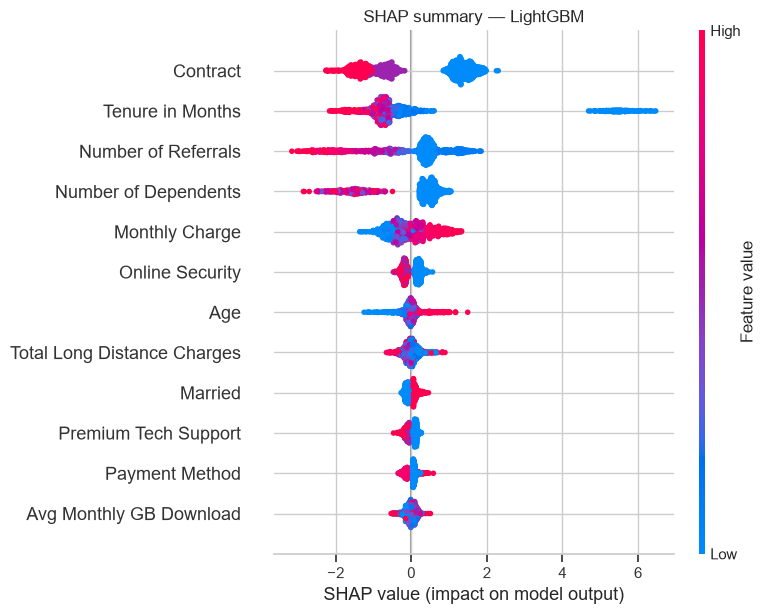

In [23]:
# Vista global clásica de SHAP para contexto (beeswarm)
shap.summary_plot(PHI_TE, X_te, max_display=12, show=False)
plt.title(f"SHAP summary — {MODEL_NAME}"); plt.tight_layout(); plt.show()

### 6.2 Métricas comparativas

Métricas de la Sección 4.4 del paper (sin AnchorTabular ni panel de expertos):

1. **Tiempo de ejecución** (media ± std, ms/instancia) — incluye el cálculo SHAP por instancia.
2. **Complejidad** — número de condiciones/features en la explicación.
3. **Cobertura** — solo SHAP-R: proporción de instancias con $\alpha \ge 0.33$.
4. **Fidelidad** — solo SHAP-R: para cada regla generada, proporción de instancias del test que satisfacen los antecedentes ($\mu>0$ en numéricas, igualdad en categóricas) y cuya predicción del modelo coincide con el consecuente (Ec. 17). Se reporta mediana ± std.
5. **Consistencia** — similitud de Levenshtein normalizada (Ec. 18) entre la explicación original y las de 10 perturbaciones gaussianas (1% de la std de cada numérica).

In [24]:
def timing_and_complexity(model, phi_fun, n_sample=200):
    idx = np.random.RandomState(0).choice(len(X_te), n_sample, replace=False)
    res = {}
    for mode in ["shap", "shap_l", "shap_r"]:
        times, compl = [], []
        for i in idx:
            t0 = time.perf_counter()
            phi = phi_fun(X_te.iloc[[i]])[0]          # SHAP por instancia (como en DSS real)
            out = explain_instance(i, phi, model, mode)
            times.append((time.perf_counter() - t0) * 1000)
            compl.append(out[2])
        res[mode] = dict(time_mean=np.mean(times), time_std=np.std(times),
                         cx_mean=np.mean(compl), cx_std=np.std(compl))
    return res

def coverage_and_fidelity(model, n_rules=150):
    # Cobertura sobre TODO el test
    alphas, rules = [], []
    for i in range(len(X_te)):
        _, a, _, pred, ants = explain_instance(i, PHI_TE[i], model, "shap_r")
        alphas.append(a)
        rules.append((a, pred, ants))
    alphas = np.array(alphas)
    coverage = float((alphas >= ALPHA_MIN).mean())

    # Fidelidad (Ec. 17) sobre una muestra de reglas activadas
    valid = [r for r in rules if r[0] >= ALPHA_MIN]
    rng = np.random.RandomState(1)
    sample = [valid[k] for k in rng.choice(len(valid), min(n_rules, len(valid)), replace=False)]
    y_hat = model.predict(X_te)
    fids = []
    for a, pred, ants in sample:
        mask = np.ones(len(X_te), dtype=bool)
        for kind, col, val in ants:
            if kind == "cat":
                mask &= (Xr_te[col].values == val)
            else:
                abc = MFS[col][val]
                mask &= np.array([tri_mu(v, *abc) > 0 for v in Xr_te[col].values])
        if mask.sum() == 0: continue
        fids.append((y_hat[mask] == pred).mean())
    return coverage, float(np.median(fids)), float(np.std(fids))

def consistency(model, phi_fun, n_sample=80, n_pert=10, noise=0.01):
    stds = Xr_tr[NUM_COLS].std()
    idx = np.random.RandomState(2).choice(len(X_te), n_sample, replace=False)
    res = {m: [] for m in ["shap", "shap_l", "shap_r"]}
    for i in idx:
        base_txt = {m: explain_instance(i, PHI_TE[i], model, m)[0] for m in res}
        x_enc, x_raw = X_te.iloc[i].copy(), Xr_te.iloc[i].copy()
        for _ in range(n_pert):
            xe, xr = x_enc.copy(), x_raw.copy()
            for col in NUM_COLS:                          # ruido solo en numéricas
                delta = np.random.normal(0, noise * stds[col])
                xe[col] += delta; xr[col] += delta
            # inyectar perturbación temporalmente
            X_te.iloc[i], Xr_te.iloc[i] = xe, xr
            phi_p = phi_fun(xe.to_frame().T)[0]
            for m in res:
                pert_txt = explain_instance(i, phi_p, model, m)[0]
                sim = 1 - Levenshtein.distance(base_txt[m], pert_txt) / max(len(base_txt[m]), len(pert_txt))
                res[m].append(sim)
            X_te.iloc[i], Xr_te.iloc[i] = x_enc, x_raw    # restaurar
    return {m: (np.mean(v), np.std(v)) for m, v in res.items()}

In [25]:
results = {}
for name, model in [("Random Forest", rf), ("LightGBM", lgbm)]:
    pf = phi_fn[name]
    globals()["PHI_TE"] = pf(X_te)   # recalcular matriz SHAP del modelo activo
    tc = timing_and_complexity(model, pf)
    cov, fid_med, fid_std = coverage_and_fidelity(model)
    cons = consistency(model, pf)
    for mode, label in [("shap", "SHAP"), ("shap_l", "SHAP-L"), ("shap_r", "SHAP-R")]:
        results[(name, label)] = {
            "Tiempo (ms)": f"{tc[mode]['time_mean']:.2f} ± {tc[mode]['time_std']:.2f}",
            "Complejidad": f"{tc[mode]['cx_mean']:.2f} ± {tc[mode]['cx_std']:.2f}",
            "Cobertura": f"{cov:.3f}" if label == "SHAP-R" else "-",
            "Fidelidad (med ± std)": f"{fid_med:.3f} ± {fid_std:.3f}" if label == "SHAP-R" else "-",
            "Consistencia": f"{cons[mode][0]:.3f} ± {cons[mode][1]:.3f}",
        }
comparison = pd.DataFrame(results).T
comparison.index.names = ["Modelo", "Método"]
comparison

Tiempo (ms)   Complejidad Cobertura  \
Modelo        Método                                         
Random Forest SHAP    30.12 ± 5.88  28.00 ± 0.00         -   
              SHAP-L  29.85 ± 6.34   4.00 ± 0.00         -   
              SHAP-R  28.66 ± 3.91   4.00 ± 0.00     0.957   
LightGBM      SHAP     8.62 ± 1.89  28.00 ± 0.00         -   
              SHAP-L  12.81 ± 3.54   3.85 ± 0.47         -   
              SHAP-R  18.11 ± 5.94   3.85 ± 0.47     0.981   

                     Fidelidad (med ± std)   Consistencia  
Modelo        Método                                       
Random Forest SHAP                       -  0.760 ± 0.070  
              SHAP-L                     -  0.794 ± 0.073  
              SHAP-R         0.949 ± 0.218  0.948 ± 0.112  
LightGBM      SHAP                       -  0.688 ± 0.109  
              SHAP-L                     -  0.639 ± 0.147  
              SHAP-R         0.849 ± 0.194  0.796 ± 0.211

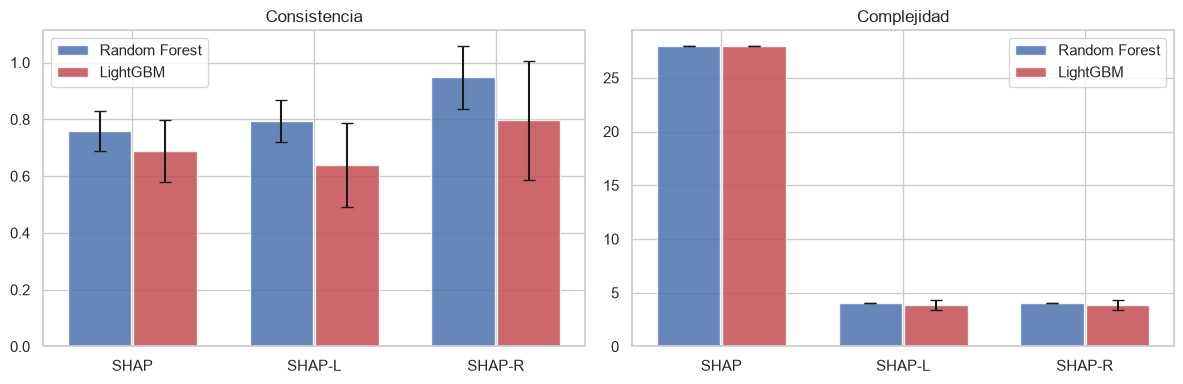

In [26]:
# Visualización comparativa de consistencia y complejidad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ["SHAP", "SHAP-L", "SHAP-R"]
for k, (metric, col) in enumerate([("Consistencia", 0), ("Complejidad", 1)]):
    for name, off, color in [("Random Forest", -0.18, "#4C72B0"), ("LightGBM", 0.18, "#C44E52")]:
        vals = [float(comparison.loc[(name, l), metric].split(" ± ")[0]) for l in labels]
        errs = [float(comparison.loc[(name, l), metric].split(" ± ")[1]) for l in labels]
        axes[k].bar(np.arange(3) + off, vals, 0.35, yerr=errs, capsize=4, label=name, color=color, alpha=0.85)
    axes[k].set_xticks(range(3)); axes[k].set_xticklabels(labels)
    axes[k].set_title(metric); axes[k].legend()
plt.tight_layout(); plt.show()

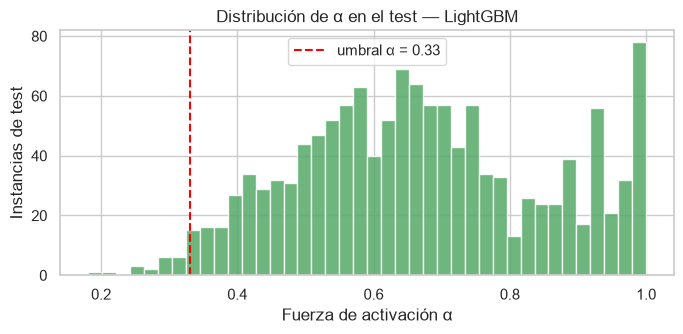

Cobertura (α ≥ 0.33): 0.981


In [27]:
# Distribución de la fuerza de activación α (SHAP-R, LightGBM)
globals()["PHI_TE"] = phi_fn["LightGBM"](X_te)
alphas = np.array([explain_instance(i, PHI_TE[i], lgbm, "shap_r")[1] for i in range(len(X_te))])
plt.figure(figsize=(7, 3.5))
plt.hist(alphas, bins=40, color="#55A868", alpha=0.85)
plt.axvline(ALPHA_MIN, color="red", ls="--", label=f"umbral α = {ALPHA_MIN}")
plt.xlabel("Fuerza de activación α"); plt.ylabel("Instancias de test")
plt.title("Distribución de α en el test — LightGBM"); plt.legend()
plt.tight_layout(); plt.show()
print(f"Cobertura (α ≥ {ALPHA_MIN}): {(alphas >= ALPHA_MIN).mean():.3f}")

## 7. Conclusiones

* **SHAP-Rule se traslada de forma natural al churn en telecom**, incluso con un conjunto de features más grande (28 vs. 19 en la v1): las reglas resultantes (p. ej. *SI Contract es Month-to-Month Y Tenure in Months es bajo Y Age es alto ENTONCES Churn*) siguen siendo directamente accionables para equipos de retención, a diferencia de los vectores numéricos de SHAP.
* Reutilizar el preprocesamiento de `eda_churn_v1.py`/`eda_p1_ml.py` (rama árboles) suma limpieza que la v1 no tenía — imputación estructural fit-free, corrección de `Monthly Charge` negativo y eliminación de multicolineales por VIF (`Total Charges`, `Total Revenue`) — sin tocar la lógica de SHAP-Rule en sí.
* La adaptación clave frente al paper (que usaba solo variables numéricas) sigue siendo tratar las **categóricas como términos lingüísticos nativos** con μ = 1; entre las numéricas, tres variables muy concentradas en cero (`Number of Dependents`, `Total Refunds`, `Total Extra Data Charges`) colapsan a un único término trivial, una limitación del método de poda frente a variables zero-inflated que no aparecía con las 3 numéricas de la v1.
* El perfil de métricas replica las tendencias del paper: **complejidad acotada** (≤ K antecedentes vs. 28 features del SHAP completo), **latencia de milisegundos** apta para DSS en tiempo real, **alta fidelidad** en el subconjunto explicado y una **cobertura** controlada por el umbral α.
* Trabajo futuro: sensibilidad sobre (K, T, α), tratamiento específico de variables zero-inflated (p. ej. términos binarios "cero" / "no cero" en vez de la partición triangular de 7 términos), evaluación subjetiva con expertos de negocio (escala Likert, Kruskal–Wallis) y comparación con AnchorTabular (librería `alibi`).